# Data Re-uploading VQC

The week 4 VQC has the same setup as the original VQC, but the circuit utilizes data reuploading to reapply the angle embedding each layer.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pennylane as qml
from pennylane import numpy as pnp

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

np.random.seed(1234)

## Load, reduce, and split the data


In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

X_scaled = StandardScaler().fit_transform(X)
X = PCA(n_components=2).fit_transform(X_scaled)
y = y * 2 - 1 
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

## Scale features for angle encoding


In [3]:
scaler = MinMaxScaler((-np.pi, np.pi)).fit(Xtr)
Xtr = scaler.transform(Xtr)
Xte = np.clip(scaler.transform(Xte), -np.pi, np.pi)

Xtr = pnp.array(Xtr)
ytr = pnp.array(ytr, dtype=float)

## Create the data-reuploading circuit

Takes the circuit and applies the angle embedding at the beginning of each of the 3 layers.

In [4]:
n_qubits = 2
n_layers = 3
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, diff_method="backprop")
def circuit(weights, x):
    for L in range(n_layers):
        qml.AngleEmbedding(x, wires=range(n_qubits))     
        for i in range(n_qubits):
            qml.Rot(weights[L, i, 0], weights[L, i, 1], weights[L, i, 2], wires=i)
        qml.CNOT(wires=[0, 1])
    return qml.expval(qml.PauliZ(0))

def model(weights, bias, x):
    return circuit(weights, x) + bias

## Circuit diagram

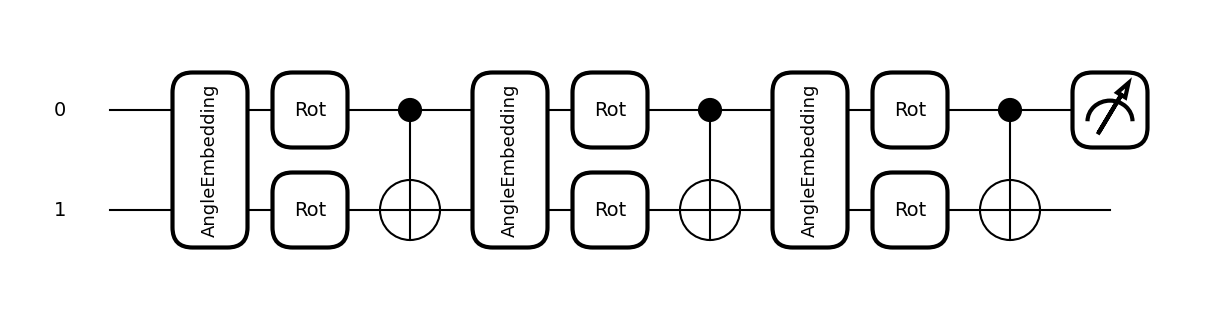

In [5]:
sample = Xtr[0]
fig, ax = qml.draw_mpl(circuit)(pnp.zeros((n_layers, n_qubits, 3)), sample)
plt.show()

## Train the model

Adjusts the circuit weights by using separate weights for each of the 3 layers to lower the loss, and save the loss each step to plot.

In [6]:
def cost(weights, bias, X, Y):
    preds = pnp.stack([model(weights, bias, x) for x in X])
    return pnp.mean((Y - preds) ** 2)

weights = pnp.array(0.01 * np.random.randn(n_layers, n_qubits, 3), requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)
opt = qml.NesterovMomentumOptimizer(0.2)

loss_history = []
for step in range(40):
    weights, bias, _, _ = opt.step(cost, weights, bias, Xtr, ytr)
    loss_history.append(float(cost(weights, bias, Xtr, ytr)))

print("final training loss:", round(loss_history[-1], 4))

final training loss: 0.2169


## Training-loss plot

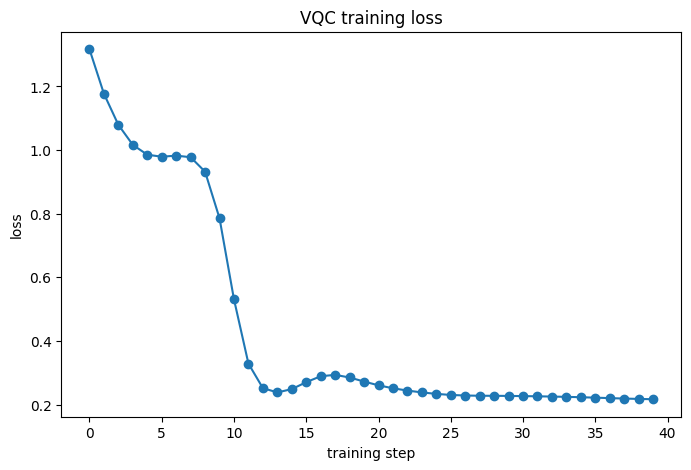

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, marker="o")
plt.xlabel("training step")
plt.ylabel("loss")
plt.title("VQC training loss")
plt.show()

## Evaluate the model
Use the sign of the model's output to predict malignant vs benign, then compute accuracy, precision, recall, and F1.

In [8]:
def predict(X):
    return np.array([1 if model(weights, bias, x) > 0 else -1 for x in X])

pred = predict(Xte)

y_true = np.where(yte == -1, 0, 1)
y_pred = np.where(pred == -1, 0, 1)

results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1"],
    "score": [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred),
    ],
})
results

,metric,score
0,accuracy,0.909091
1,precision,0.923077
2,recall,0.933333
3,f1,0.928177


## Generate model output over an input grid

Evaluate the trained model across the 2D feature space so the decision surface can be seen.

In [ ]:
n_grid = 100

g = np.linspace(-np.pi, np.pi, n_grid)
GX, GY = np.meshgrid(g, g)
grid = np.column_stack([GX.ravel(), GY.ravel()])

Z = np.array([float(model(weights, bias, pnp.array(p))) for p in grid])
Z = Z.reshape(GX.shape)

print("grid shape:", Z.shape, " output range:", round(Z.min(), 3), "to", round(Z.max(), 3))

grid shape: (100, 100)  output range: -0.958 to 0.979


## Decision surface and boundary

The heatmap shows the model's raw output across the feature space. The black line is the decision boundary, where the output crosses zero and the predicted class flips.

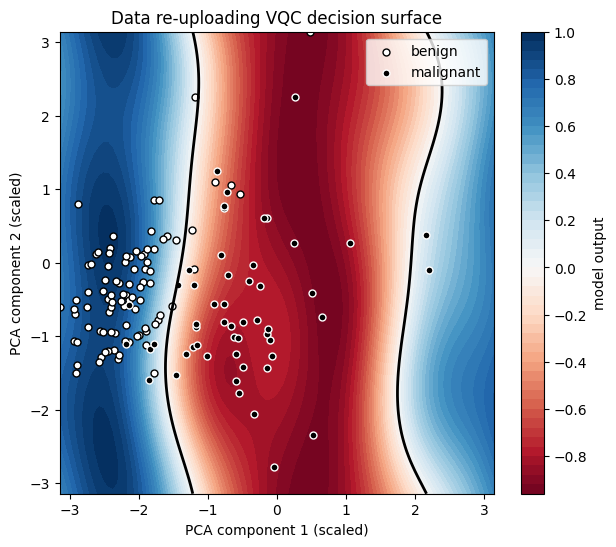

In [10]:
lim = np.abs(Z).max()

fig, ax = plt.subplots(figsize=(7, 6))
hm = ax.contourf(GX, GY, Z, levels=50, cmap="RdBu", vmin=-lim, vmax=lim)
plt.colorbar(hm, ax=ax, label="model output")
ax.contour(GX, GY, Z, levels=[0], colors="black", linewidths=2)

ax.scatter(Xte[yte == 1, 0], Xte[yte == 1, 1], c="white", edgecolors="black", s=25, label="benign")
ax.scatter(Xte[yte == -1, 0], Xte[yte == -1, 1], c="black", edgecolors="white", s=25, label="malignant")

ax.set_xlabel("PCA component 1 (scaled)")
ax.set_ylabel("PCA component 2 (scaled)")
ax.set_title("Data re-uploading VQC decision surface")
ax.legend()
plt.show()